# Analysis of MNase-seq replication timing

March 29, 2024

Updated replication timing analysis with realigned 60 minute BAM



In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [71]:
mnase_analysis = MNaseOriginAnalysis()

In [72]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [73]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

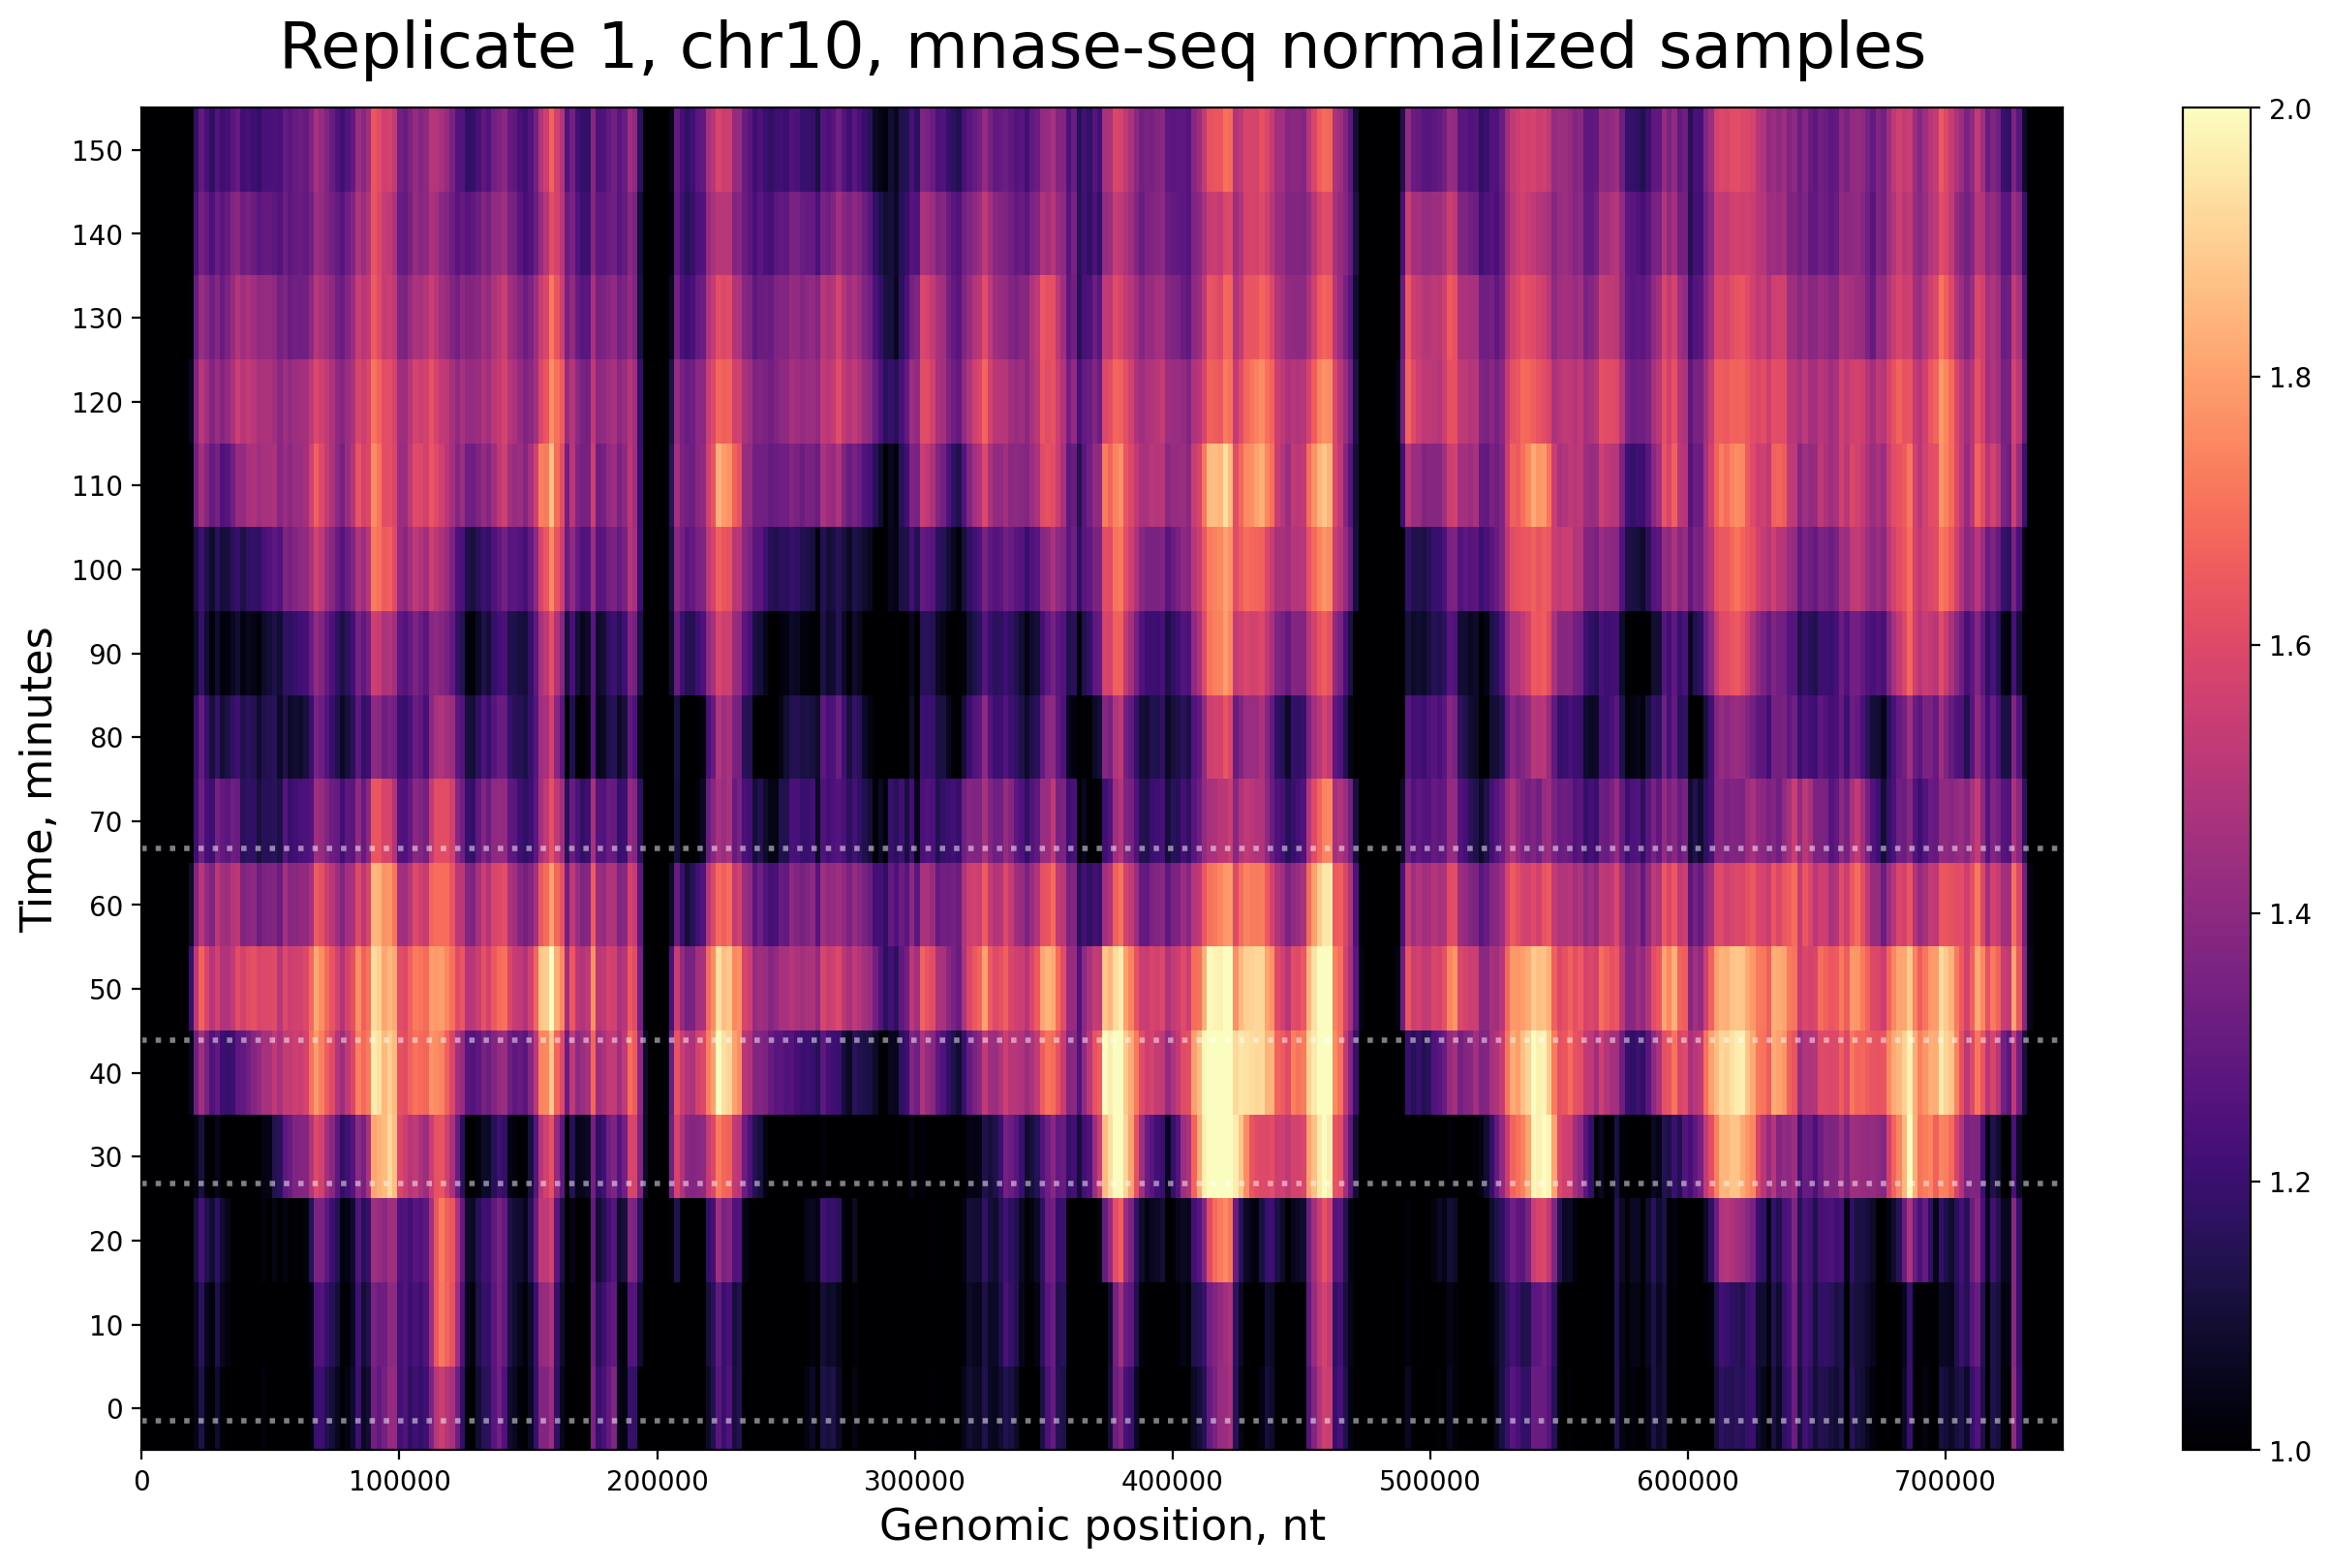

In [74]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

In [75]:
def get_bin_for_position(mnase_analysis, position):
    """Get the bin in which the position is the closest to the center of the bin"""

    start_indices = mnase_analysis.start_indices
    win = mnase_analysis.window_size
    win_2 = win//2
    step = mnase_analysis.step

    position_bin_idx = np.argmin((position - win_2) > start_indices)
    bin_start = position_bin_idx * step
    bin_end = bin_start + win

    return position_bin_idx, bin_start

get_bin_for_position(mnase_analysis, 5500)

(1, 2000)

In [150]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

Text(0.5, 0.98, 'Non-zero bin normalization, Replicate 1, chr10')

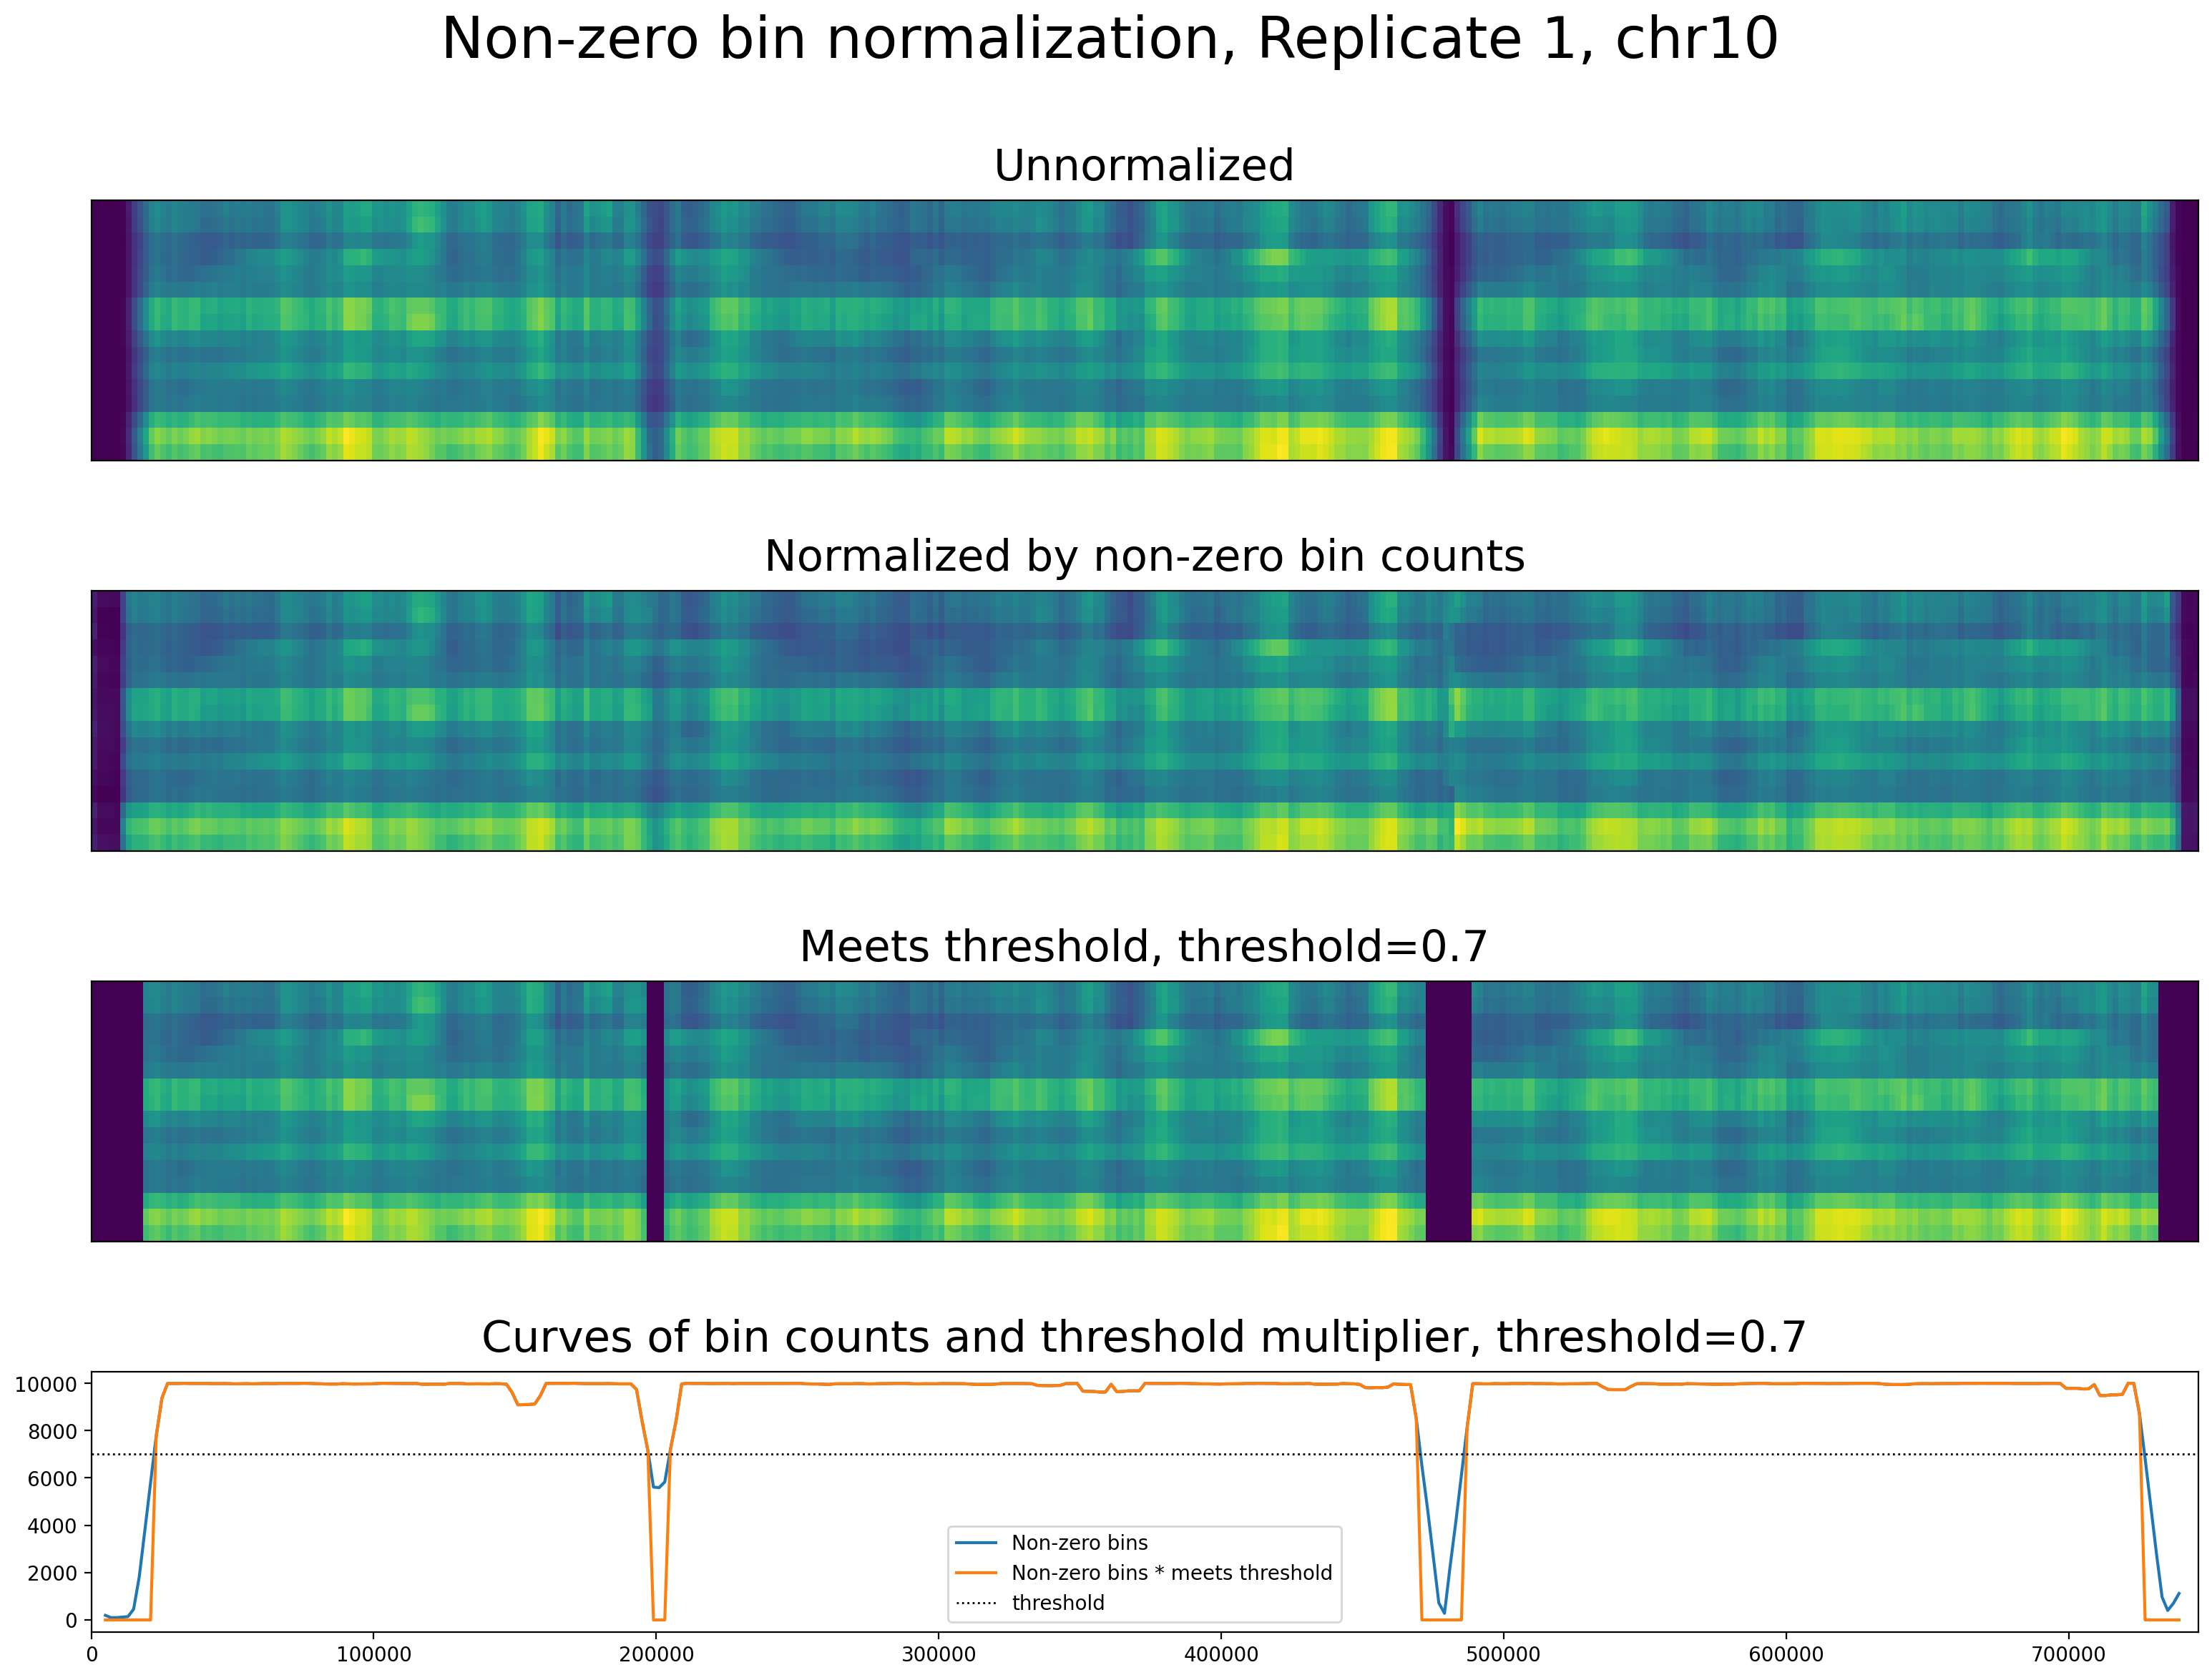

In [176]:
plt.figure(figsize=(19, 13))
plt.subplots_adjust(hspace=0.5)
plt.subplot(4, 1, 1)
plt.imshow(mnase_analysis.all_window_counts_nonzero_unhandled, aspect='auto')
plt.xticks([])
plt.yticks([])
plt.title("Unnormalized",
          fontsize=22, pad=10)

plt.subplot(4, 1, 2)
plt.imshow(mnase_analysis.all_window_counts_nonzero_handled, aspect='auto')
plt.xticks([])
plt.yticks([])
plt.title("Normalized by non-zero bin counts",
          fontsize=22, pad=10)

plt.subplot(4, 1, 3)
plt.imshow(mnase_analysis.all_window_counts, aspect='auto')
plt.xticks([])
plt.yticks([])
plt.title(f"Meets threshold, threshold={mnase_analysis.min_count_thresh}",
          fontsize=22, pad=10)

# Identify a cutoff in which we should zero out the count curves
plt.subplot(4, 1, 4)
xs = mnase_analysis.start_indices + mnase_analysis.window_size//2
plt.plot(xs, mnase_analysis.total_nonzero_bins_per_10k,
    label="Non-zero bins")
plt.plot(xs, 
    mnase_analysis.total_nonzero_bins_per_10k * mnase_analysis.meets_threshold,
        label="Non-zero bins * meets threshold")
plt.xlim(0, mnase_analysis.chrom_len)
plt.axhline(mnase_analysis.min_count_thresh * mnase_analysis.window_size, c='black',
           lw=1, ls='dotted', label='threshold')
plt.title(f"Curves of bin counts and threshold multiplier, threshold={mnase_analysis.min_count_thresh}",
          fontsize=22, pad=10)
plt.legend()
plt.suptitle(f"Non-zero bin normalization, Replicate {mnase_analysis.replicate},"
             f" chr{mnase_analysis.chromosome}", fontsize=29)
